In [1]:
# 1. IMPORTAR LIBRERÍAS
# =========================================================
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)


In [2]:
# =========================================================
# 2. CARGAR EL CSV PREPROCESADO
# =========================================================

csv_path = "natalidad_preprocesado_ucin.csv"  

print("Archivo encontrado:", csv_path)

df = pd.read_csv(csv_path)

print("Dimensiones del dataset:", df.shape)
print(df.head())

Archivo encontrado: natalidad_preprocesado_ucin.csv
Dimensiones del dataset: (3668913, 69)
   dob_mm  dob_tt  dob_wk  bfacil  mager  mbstate_rec  restatus  mrace6  \
0       2     600       1       1   38.0            2         1       1   
1       7    2024       5       1   30.0            2         1       1   
2       3     430       5       1   29.0            2         1       1   
3       6    1210       1       1   37.0            1         1       4   
4       1    2009       3       1   22.0            2         1       5   

   mrace15  mhispx  ...  ca_anen  ca_mnsb  ca_cchd  ca_cdh  ca_omph  ca_gast  \
0        1       4  ...        0        0        0       0        0        0   
1        1       4  ...        0        0        0       0        0        0   
2        1       4  ...        0        0        0       0        0        0   
3       10       0  ...        0        0        0       0        0        0   
4       14       0  ...        0        0        0       0

In [3]:
# =========================================================
# 3. DEFINIR VARIABLES PREDICTORAS (X) Y TARGET (y)
# =========================================================

target = "ucin"

# Verificar que exista la variable objetivo
if target not in df.columns:
    raise ValueError(f"No se encontró la columna target '{target}' en el dataset.")

# Variables predictoras y target
X = df.drop(columns=[target])
y = df[target]

# =========================================================
# INFORMACIÓN GENERAL DEL DATASET
# =========================================================

print("\nNúmero de variables predictoras:", X.shape[1])

print("\nVariables finales del modelo:")
print(X.columns.tolist())

# =========================================================
# DISTRIBUCIÓN DEL TARGET
# =========================================================

print("\nDistribución absoluta del target:")
print(y.value_counts())

print("\nDistribución porcentual del target:")
dist = (y.value_counts(normalize=True) * 100).round(2)
print(dist)


Número de variables predictoras: 68

Variables finales del modelo:
['dob_mm', 'dob_tt', 'dob_wk', 'bfacil', 'mager', 'mbstate_rec', 'restatus', 'mrace6', 'mrace15', 'mhispx', 'dmar', 'meduc', 'feduc', 'priorlive', 'priordead', 'priorterm', 'precare', 'previs', 'wic', 'cig_0', 'm_ht_in', 'bmi', 'wtgain', 'rf_pdiab', 'rf_gdiab', 'rf_phype', 'rf_ghype', 'rf_ehype', 'rf_ppterm', 'rf_inftr', 'rf_cesar', 'ip_gon', 'ip_syph', 'ip_chlam', 'ip_hepb', 'ip_hepc', 'ob_ecvs', 'ld_augm', 'ld_ster', 'ld_antb', 'ld_chor', 'ld_anes', 'me_pres', 'me_rout', 'mm_mtr', 'mm_plac', 'mm_rupt', 'mm_uhyst', 'attend', 'mtran', 'pay', 'apgar5', 'sex', 'dlmp_mm', 'combgest', 'dbwt', 'ab_aven1', 'ab_aven6', 'ab_seiz', 'ca_anen', 'ca_mnsb', 'ca_cchd', 'ca_cdh', 'ca_omph', 'ca_gast', 'ca_limb', 'ca_cleft', 'ca_clpal']

Distribución absoluta del target:
ucin
0    3320763
1     348150
Name: count, dtype: int64

Distribución porcentual del target:
ucin
0    90.51
1     9.49
Name: proportion, dtype: float64


In [4]:
# =========================================================
# 4. DIVISIÓN ENTRENAMIENTO / PRUEBA
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

# =========================================================
# DISTRIBUCIÓN DEL TARGET
# =========================================================

print("\nDistribución y_train (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución y_test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))


Tamaño X_train: (2935130, 68)
Tamaño X_test: (733783, 68)

Distribución y_train (%):
ucin
0    90.51
1     9.49
Name: proportion, dtype: float64

Distribución y_test (%):
ucin
0    90.51
1     9.49
Name: proportion, dtype: float64


In [5]:
# =========================================================
# 5. BALANCEO DE CLASES CON SMOTE
# =========================================================

from imblearn.over_sampling import SMOTE

# Convertir variables predictoras a formato numérico ligero
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(
    sampling_strategy=0.3,
    random_state=42,
    k_neighbors=3
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribución antes de SMOTE:")
print(y_train.value_counts())

print("\nDistribución después de SMOTE:")
print(y_train_res.value_counts())

Distribución antes de SMOTE:
ucin
0    2656610
1     278520
Name: count, dtype: int64

Distribución después de SMOTE:
ucin
0    2656610
1     796983
Name: count, dtype: int64


In [6]:
# =========================================================
# 6. CREAR MODELO RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(

    n_estimators=200,       # número de árboles
    max_depth=18,           # profundidad máxima de cada árbol

    min_samples_split=10,   # mínimo de muestras para dividir un nodo
    min_samples_leaf=4,     # mínimo de muestras por hoja

    max_features="sqrt",    # variables evaluadas en cada división

    class_weight=None,      # SMOTE ya realiza el balanceo

    oob_score=True,         # evaluación interna del modelo

    random_state=42,
    n_jobs=-1               # usar todos los núcleos disponibles
)

In [7]:
# =========================================================
# 7. ENTRENAR MODELO
# =========================================================

rf_model.fit(X_train_res, y_train_res) #entreno con datos del train balanceados por smote

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [8]:
# =========================================================
# 8. BÚSQUEDA DEL MEJOR UMBRAL SEGÚN RECALL OBJETIVO
# =========================================================

import numpy as np
import pandas as pd

recall_objetivo = 0.80

# Probabilidades de clase positiva: UCIN = 1
y_proba = rf_model.predict_proba(X_test)[:, 1]

umbrales = np.arange(0.10, 0.91, 0.01)

resultados_umbral = []

for umbral in umbrales:
    y_pred = (y_proba >= umbral).astype(int)

    resultados_umbral.append({
        "umbral": umbral,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "diferencia_recall": abs(recall_score(y_test, y_pred, zero_division=0) - recall_objetivo)
    })

df_umbral = pd.DataFrame(resultados_umbral)

mejor_umbral = df_umbral.sort_values(
    by=["diferencia_recall", "f1_score"],
    ascending=[True, False]
).iloc[0]

print("================= MEJOR UMBRAL RANDOM FOREST =================")
print(f"Recall objetivo : {recall_objetivo:.2f}")
print(f"Umbral elegido  : {mejor_umbral['umbral']:.2f}")
print(f"Accuracy        : {mejor_umbral['accuracy']:.4f}")
print(f"Precision       : {mejor_umbral['precision']:.4f}")
print(f"Recall          : {mejor_umbral['recall']:.4f}")
print(f"F1-score        : {mejor_umbral['f1_score']:.4f}")

print("\nTop 10 umbrales más cercanos al recall objetivo:")
print(df_umbral.sort_values(by="diferencia_recall").head(10))

================= MEJOR UMBRAL RANDOM FOREST =================
Recall objetivo : 0.80
Umbral elegido  : 0.11
Accuracy        : 0.8638
Precision       : 0.3925
Recall          : 0.7946
F1-score        : 0.5255

Top 10 umbrales más cercanos al recall objetivo:
   umbral  accuracy  precision    recall  f1_score  diferencia_recall
1    0.11  0.863821   0.392532  0.794614  0.525482           0.005386
0    0.10  0.853470   0.373951  0.807210  0.511119           0.007210
2    0.12  0.874744   0.415095  0.782206  0.542369           0.017794
3    0.13  0.885229   0.440021  0.768448  0.559606           0.031552
4    0.14  0.893989   0.464012  0.755407  0.574893           0.044593
5    0.15  0.900704   0.484869  0.743702  0.587020           0.056298
6    0.16  0.905944   0.503018  0.733750  0.596861           0.066250
7    0.17  0.909896   0.518032  0.724702  0.604182           0.075298
8    0.18  0.913146   0.531430  0.716114  0.610102           0.083886
9    0.19  0.916057   0.544398  0.707396 

In [11]:
# =========================================================
# 8. PREDICCIONES
# =========================================================

# Probabilidad de ingreso en UCIN
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Umbral común 
umbral = 0.10

# Convertir probabilidades en clases
y_pred = (y_proba >= umbral).astype(int)


================= MÉTRICAS RANDOM FOREST =================
Umbral   : 0.10
Accuracy : 0.8535
Precision: 0.3740
Recall   : 0.8072
F1-score : 0.5111
AUC-ROC  : 0.9024

================= CLASSIFICATION REPORT =================
              precision    recall  f1-score   support

           0     0.9770    0.8583    0.9138    664153
           1     0.3740    0.8072    0.5111     69630

    accuracy                         0.8535    733783
   macro avg     0.6755    0.8328    0.7125    733783
weighted avg     0.9198    0.8535    0.8756    733783



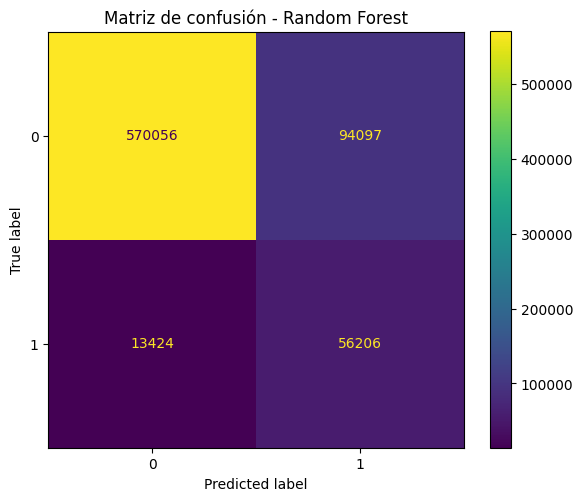

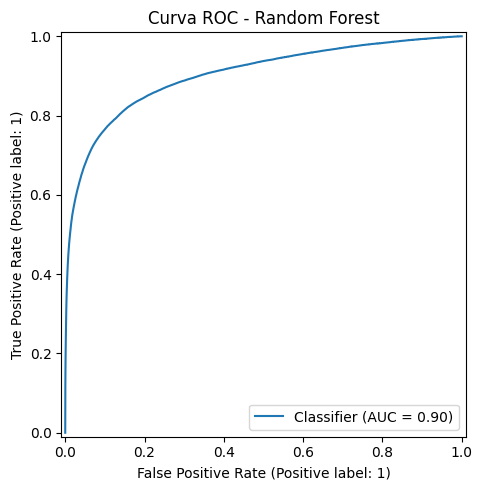


================= TOP 15 VARIABLES MÁS IMPORTANTES =================
     Variable  Importancia
56   ab_aven1     0.181715
51     apgar5     0.126328
54   combgest     0.122326
55       dbwt     0.116776
57   ab_aven6     0.083391
38    ld_ster     0.059950
43    me_rout     0.044675
39    ld_antb     0.040419
26   rf_ghype     0.021324
6    restatus     0.019296
30   rf_cesar     0.017648
42    me_pres     0.013142
15  priorterm     0.011468
17     previs     0.010980
37    ld_augm     0.010112


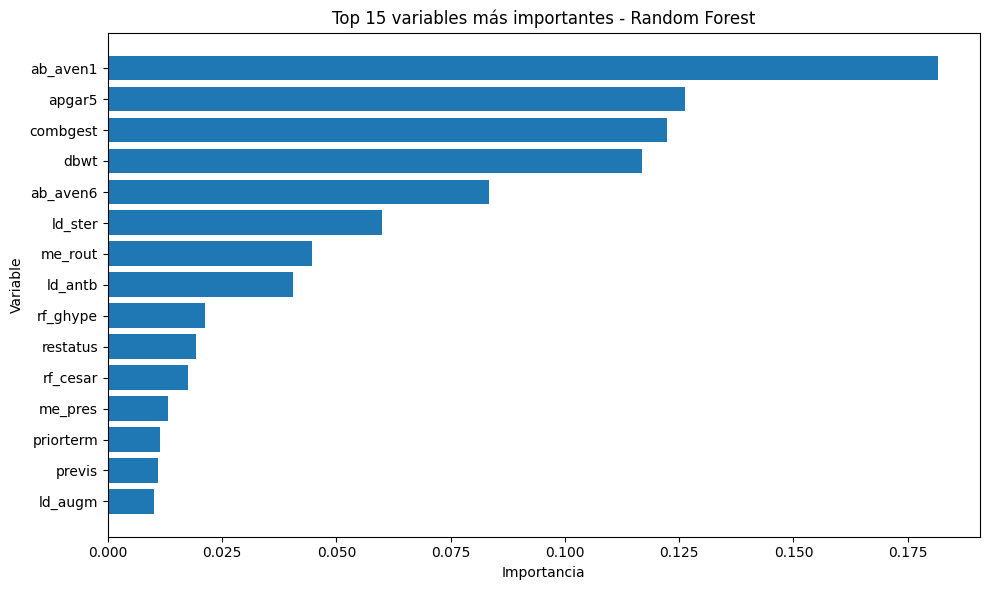


Ejemplo de resultados:
         dob_mm  dob_tt  dob_wk  bfacil  mager  mbstate_rec  restatus  mrace6  \
3177067     5.0  1121.0     3.0     1.0   25.0          1.0       2.0     1.0   
2494307     7.0  1329.0     6.0     1.0   31.0          1.0       1.0     2.0   
2834635     5.0  1720.0     5.0     1.0   34.0          1.0       1.0     1.0   
1113169     2.0   405.0     5.0     1.0   27.0          1.0       1.0     1.0   
493874      7.0  1457.0     5.0     1.0   30.0          1.0       2.0     1.0   

         mrace15  mhispx  ...  ca_cchd  ca_cdh  ca_omph  ca_gast  ca_limb  \
3177067      1.0     6.0  ...      0.0     0.0      0.0      0.0      0.0   
2494307      2.0     0.0  ...      0.0     0.0      0.0      0.0      0.0   
2834635      1.0     0.0  ...      0.0     0.0      0.0      0.0      0.0   
1113169      1.0     0.0  ...      0.0     0.0      0.0      0.0      0.0   
493874       1.0     1.0  ...      0.0     0.0      0.0      0.0      0.0   

         ca_cleft  ca_clpa

In [12]:
# =========================================================
# 9. MÉTRICAS
# =========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("\n================= MÉTRICAS RANDOM FOREST =================")
print(f"Umbral   : {umbral:.2f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

print("\n================= CLASSIFICATION REPORT =================")
print(classification_report(y_test, y_pred, digits=4))


# =========================================================
# 10. MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(values_format="d", ax=ax)
ax.set_title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()


# =========================================================
# 11. CURVA ROC
# =========================================================

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.set_title("Curva ROC - Random Forest")
plt.tight_layout()
plt.show()


# =========================================================
# 12. IMPORTANCIA DE VARIABLES
# =========================================================

importance_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\n================= TOP 15 VARIABLES MÁS IMPORTANTES =================")
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Variable"].head(15)[::-1],
    importance_df["Importancia"].head(15)[::-1]
)
plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


# =========================================================
# 13. GUARDAR RESULTADOS
# =========================================================

importance_df.to_csv("importancia_variables_random_forest.csv", index=False)

resultados = X_test.copy()
resultados["y_real"] = y_test.values
resultados["y_pred"] = y_pred
resultados["prob_ucin"] = y_proba

print("\nEjemplo de resultados:")
print(resultados.head())

resultados.to_csv("predicciones_random_forest.csv", index=False)